# Building ChatBot with Multiple Tools

Integrate with arxiv, wikipedia search, tavily search engine

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage
from typing_extensions import TypedDict
from typing import Annotated
from langchain_core.messages import AIMessage,HumanMessage
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langchain_ollama import ChatOllama

C:\Users\Hanif\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
tavily_api_key = os.getenv("TAVILY_API_KEY")

In [24]:
from langchain_groq import ChatGroq
GROQ_API_KEY= os.getenv('GROQ_API_KEY')
llm = ChatOllama(model='llama3.1:8b')
llm.invoke('Hi Llama  what is your model name?')

AIMessage(content='I\'m an electric AI assistant, but my model name is not publicly disclosed. However, I can tell you that I was trained on a variant of the T5 (Text-to-Text Transfer Transformer) model architecture, which is a popular and powerful language model developed by Google. But don\'t worry, I don\'t have a specific "name" like a human would – my purpose is to assist and communicate with users in a helpful way!', additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2025-07-08T14:27:49.4136666Z', 'done': True, 'done_reason': 'stop', 'total_duration': 14494099800, 'load_duration': 7210832800, 'prompt_eval_count': 20, 'prompt_eval_duration': 871756500, 'eval_count': 90, 'eval_duration': 6404325000, 'model_name': 'llama3.1:8b'}, id='run--04d191a4-1acb-4311-8e1b-9b83b4852d68-0', usage_metadata={'input_tokens': 20, 'output_tokens': 90, 'total_tokens': 110})

In [20]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [5]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=1000)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
arxiv.invoke('What is the latest research on LLMs?')

'Published: 2024-12-18\nTitle: LLMSA: A Compositional Neuro-Symbolic Approach to Compilation-free and Customizable Static Analysis\nAuthors: Chengpeng Wang, Yifei Gao, Wuqi Zhang, Xuwei Liu, Qingkai Shi, Xiangyu Zhang\nSummary: Static analysis is essential for program optimization, bug detection, and\ndebugging, but its reliance on compilation and limited customization hampers\npractical use. Advances in LLMs enable a new paradigm of compilation-free,\ncustomizable analysis via prompting. LLMs excel in interpreting program\nsemantics on small code snippets and allow users to define analysis tasks in\nnatural language with few-shot examples. However, misalignment with program\nsemantics can cause hallucinations, especially in sophisticated semantic\nanalysis upon lengthy code snippets.\n  We propose LLMSA, a compositional neuro-symbolic approach for\ncompilation-free, customizable static analysis with reduced hallucinations.\nSpecifically, we propose an analysis policy language to suppo

In [6]:
api_wrapper_wikipedia = WikipediaAPIWrapper(top_k_results=2,doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wikipedia)
wiki.name

'wikipedia'

In [7]:
wiki.invoke('Large Language Models')

'Page: Large language model\nSummary: A large language model (LLM) is a language model trained with self-supervised machine learning on a vast amount of text, designed for natural language processing tasks, especially language generation.\nThe largest and most capable LLMs are generative pretrained transformers (GPTs), which are largely used in generative chatbots such as ChatGPT, Gemini or Claude. LLMs can be fine-tuned for specific tasks or guided by prompt engineering. These models acquire predi'

In [10]:
# add Tavily Search Engine
from langchain_community.tools import TavilySearchResults
tavily_search_engine = TavilySearchResults(tavily_api_key=tavily_api_key,top_k=2)

In [11]:
tavily_search_engine.invoke('What is the lastest news AI LLM?')

[{'title': 'AI News | Latest AI News, Analysis & Events',
  'url': 'https://www.artificialintelligence-news.com/',
  'content': '### Anthropic tests AI running a real business with bizarre results\n\nApplications\n\nJune 27, 2025\n\n#### Machine Learning\n\n### Salesforce to buy Informatica in $8B deal\n\nArtificial Intelligence\n\nMay 28, 2025\n\n### Huawei Supernode 384 disrupts Nvidia’s AI market hold\n\nArtificial Intelligence\n\nMay 28, 2025\n\n### OpenAI’s latest LLM opens doors for China’s AI startups\n\nAlibaba\n\nApril 29, 2025\n\nImage 23\n\nImage 24\n\nImage 25\n\n#### Enterprise\n\n### Flood of interest in Europe’s AI Gigafactories plan [...] Companies\n\nJuly 3, 2025\n\n#### Deep Learning\n\n### RAGEN: AI framework tackles LLM agent instability\n\nApplications\n\nApril 24, 2025\n\n### Alibaba Qwen QwQ-32B: Scaled reinforcement learning showcase\n\nAlibaba\n\nMarch 6, 2025\n\n### DeepSeek-R1 reasoning models rival OpenAI in performance\n\nArtificial Intelligence\n\nJanuary 

In [12]:
# combine all tools
tools = [arxiv,wiki,tavily_search_engine]

In [25]:
llm_with_tools = llm.bind_tools(tools)

In [26]:
llm_with_tools.invoke([HumanMessage(content="What is the recent AI research?")])

AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2025-07-08T14:28:15.5392062Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1755453400, 'load_duration': 39787400, 'prompt_eval_count': 369, 'prompt_eval_duration': 429012200, 'eval_count': 19, 'eval_duration': 1284118100, 'model_name': 'llama3.1:8b'}, id='run--3dd8467d-f731-4ebd-befa-fde8bab3acb5-0', tool_calls=[{'name': 'arxiv', 'args': {'query': 'recent ai research'}, 'id': '252993b2-7337-4626-bc00-f4634f1f2849', 'type': 'tool_call'}], usage_metadata={'input_tokens': 369, 'output_tokens': 19, 'total_tokens': 388})

In [27]:
llm_with_tools.invoke([HumanMessage(content="What is the recent AI research?")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI research'},
  'id': '0d1e1df3-4b83-441e-85ed-ee362e8455dc',
  'type': 'tool_call'}]

Compile Entire ChatBot Graph

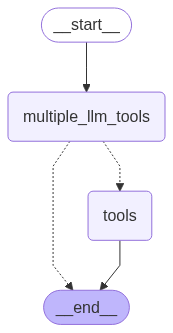

In [29]:
# Add tools condition to integrate tools with LLM
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage
from typing_extensions import TypedDict
from typing import Annotated

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

### create tools node functionality
def llm_tools(state:State):
    return {'messages':[llm_with_tools.invoke(state['messages'])]}


# Initial Graph and Node
tool_graph = StateGraph(State)
tool_graph.add_node('multiple_llm_tools',llm_tools)
tool_graph.add_node('tools',ToolNode(tools))


# Add Conditional Edge
tool_graph.add_edge(START, 'multiple_llm_tools')
tool_graph.add_conditional_edges('multiple_llm_tools',tools_condition)
tool_graph.add_edge('tools', END)

compiled_tool_graph = tool_graph.compile()
display(Image(compiled_tool_graph.get_graph().draw_mermaid_png()))

In [30]:
response = compiled_tool_graph.invoke({'messages':'who is pep guardiola?'})

for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

who is pep guardiola?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (1f657578-de34-493e-99e4-97babac369bf)
 Call ID: 1f657578-de34-493e-99e4-97babac369bf
  Args:
    query: Pep Guardiola
================================= Tool Message =================================
Name: wikipedia

Page: Pep Guardiola
Summary: Josep "Pep" Guardiola Sala (Catalan pronunciation: [ˈpɛb ɡwəɾðiˈɔlə]; born 18 January 1971) is a Catalan professional football manager and former player from Spain who has been the manager of Premier League club Manchester City since 2016. Guardiola is one of two managers in history to win the continental treble twice and he holds the record for the most consecutive league games won in La Liga, Bundesliga, and the Premier League. He is considered to be one of the gre


In [31]:
response = compiled_tool_graph.invoke({'messages':'what is AI utilization prediction in 2025 based on BCG, Deloitte, and McKinsey reports?'})

for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

what is AI utulization prediction in 2025 based on BCG, Deloitte, and McKinsey reports?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (3cadd20a-db87-434c-9acd-5f0b5b60d37c)
 Call ID: 3cadd20a-db87-434c-9acd-5f0b5b60d37c
  Args:
    query: AI utilization prediction 2025 based on BCG, Deloitte, and McKinsey reports
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Deloitte Global's 2025 Predictions Report: Generative AI", "url": "https://www.deloitte.com/global/en/about/press-room/deloitte-globals-2025-predictions-report.html", "content": "AI agents are on the rise with 25% enterprise adoption expected by 2025\n\nDeloitte predicts that 25% of enterprises using GenAI are expected to deploy AI agents in 2025, growing to 50% by 2027. The growth of AI agents—so

In [32]:
response = compiled_tool_graph.invoke({'messages':'what is AI top paper in ArXiv in June 2025?'})

for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

what is AI top paper in ArXiv in June 2025?
================================== Ai Message ==================================
Tool Calls:
  arxiv (809f3de9-edf6-422b-a55d-785d3fd30e34)
 Call ID: 809f3de9-edf6-422b-a55d-785d3fd30e34
  Args:
    query: AI top paper in ArXiv in June 2025
================================= Tool Message =================================
Name: arxiv

Published: 2023-12-09
Title: NLLG Quarterly arXiv Report 09/23: What are the most influential current AI Papers?
Authors: Ran Zhang, Aida Kostikova, Christoph Leiter, Jonas Belouadi, Daniil Larionov, Yanran Chen, Vivian Fresen, Steffen Eger
Summary: Artificial Intelligence (AI) has witnessed rapid growth, especially in the
subfields Natural Language Processing (NLP), Machine Learning (ML) and Computer
Vision (CV). Keeping pace with this rapid progress poses a considerable
challenge for researchers and professionals in the field. In t